### 🔁 What is Iterative Retrieval in Agentic RAG?
Combined both Iterative And Self reflection

✅ Definition:
Iterative Retrieval is a dynamic strategy where an AI agent doesn't settle for the first batch of retrieved documents. Instead, it evaluates the adequacy of the initial context, and if necessary, it:

- Refines the query,
- Retrieves again,
- Repeats the process until it’s confident enough to answer the original question.

🧠 Why Use It?
In standard RAG:

- A single retrieval step is done, and the LLM uses it to answer.
- If the documents were incomplete or irrelevant, the answer may fail.

In Iterative RAG:

- The agent reflects on the retrieved content and the answer it produced.
- If it’s unsure, it can refine its search (like a human researcher would).

In [8]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [9]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-5.4")

In [10]:
### Load And Embed Documents
docs = TextLoader("research_notes.txt", encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vectorstore.as_retriever()

In [11]:
### Define Agent State

class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0


In [12]:
### Retrieve Node
def retrieve_docs(state: IterativeRAGState) -> IterativeRAGState:
    query = state.refined_question or state.question
    docs = retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs": docs})


In [13]:
### Reflect And Verify
def generate_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    response = llm.invoke(prompt.strip()).content.strip()
    return state.model_copy(update={"answer": response, "attempts": state.attempts + 1})

In [14]:
## Reflect on answer
def reflect_on_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
Evaluate whether the answer below is factually sufficient and complete.

Question: {state.question}
Answer: {state.answer}

Respond 'YES' if it's complete, otherwise 'NO' with feedback.
"""
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified": verified})


In [15]:
## Refine query
def refine_query(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.

Original Question: {state.question}
Current Answer: {state.answer}
"""
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question": new_query})


In [16]:
builder = StateGraph(IterativeRAGState)

builder.add_node("retrieve", retrieve_docs)
builder.add_node("answer", generate_answer)
builder.add_node("reflect", reflect_on_answer)
builder.add_node("refine", refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer", "reflect")

builder.add_conditional_edges(
    "reflect",
    lambda s: END if s.verified or s.attempts >= 2 else "refine"
)

builder.add_edge("refine", "retrieve")
builder.add_edge("answer", END)

graph = builder.compile()


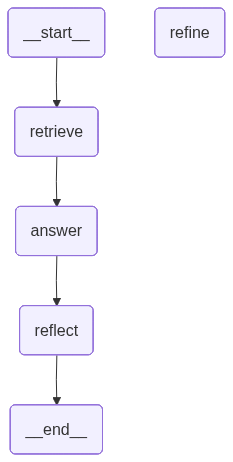

In [19]:
graph

In [17]:
query = "agent loops  and transformer-based systems?"

initial_state = IterativeRAGState(question=query)
final = graph.invoke(initial_state)

print("✅ Final Answer:\n", final["answer"])
print("\n🧠 Verified:", final["verified"])
print("🔁 Attempts:", final["attempts"])


✅ Final Answer:
 From the context, **agent loops** and **transformer-based systems** relate like this:

- **Transformer-based systems**:
  - **LLaMA2** is the main transformer model used for chatbot Q&A.
  - It was instruction-tuned on **20k internal support tickets**.
  - **TinyBERT** is another transformer-based model, used for **support ticket priority classification**.
  - LLaMA2 performance was improved with:
    - **RAG**
    - **FlashAttention2** for lower latency
    - **Chain-of-Thought** and **reflective prompting**
    - Safety layers like **Detoxify** and zero-shot out-of-scope filtering

- **Agent loops**:
  - The context points to this under **tool-augmented prompting** with **LangGraph + Wikipedia + SQL search**.
  - This setup enables **dynamic retrieval-agent reasoning**, meaning the system can iteratively:
    1. interpret the task,
    2. call tools like SQL or Wikipedia,
    3. combine evidence,
    4. refine the response.
  - Example: *“Give me customer insights fr

In [18]:
final

{'question': 'agent loops  and transformer-based systems?',
 'refined_question': 'A better query would be:\n\n**“What does the context say about agent loops or iterative/reflective reasoning in transformer-based systems, especially in relation to LLaMA2 + RAG, Chain-of-Thought prompting, reflective prompting, and long-context/latency tradeoffs?”**\n\nOther strong variants:\n\n1. **“Are agent loops explicitly mentioned in the context, or can they be inferred from iterative transformer workflows such as retrieve-reason-verify-revise?”**\n\n2. **“How do transformer-based systems in the context support agent-like loops, including RAG pipelines, Chain-of-Thought, reflective prompting, and fact-verification steps?”**\n\n3. **“Which transformer systems discussed in the context are most relevant to agent loops, and what evidence is given about multi-step reasoning, self-reflection, factuality, and latency?”**\n\nWhy this is better:\n- It replaces the vague fragment **“agent loops and transform

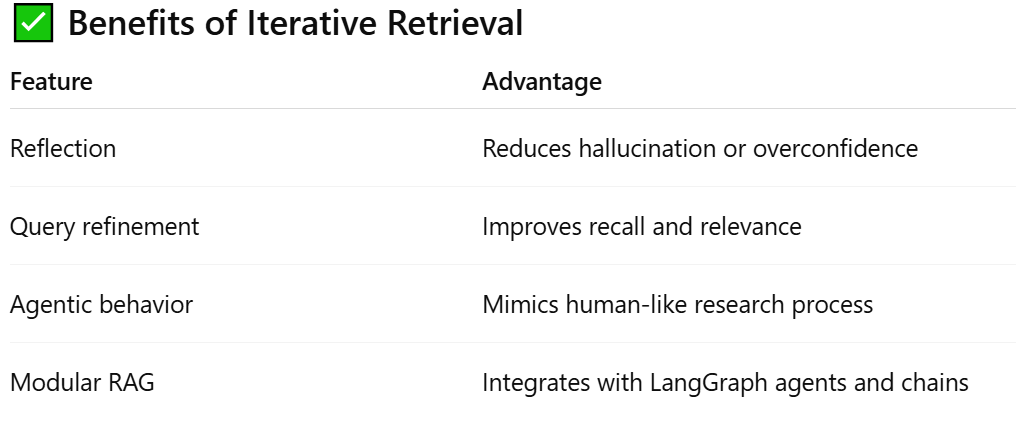